# Reconnaissance d'expressions faciales (FER2013)

Projet Deep Learning - Duc Duy et Simon

But : reconnaître 7 expressions (angry, disgust, fear, happy, neutral, sad, surprise) sur des visages 48x48 en niveaux de gris.

Dataset : FER2013, Kaggle `msambare/fer2013`

Plan :
1. données
2. baseline dense
3. CNN
4. entraînement
5. évaluation et erreurs
6. expériences

et une démo à la fin.

### Étape 0 - config

À lancer en premier. On définit les constantes utilisées partout (dossier des données, classes, taille des images, seed) et on télécharge FER2013 avec kagglehub si `data/fer2013` n'existe pas encore. Ensuite on supprime les images vides : FER2013 contient quelques images unies (toutes noires ou grises, sans visage) qui n'apprennent que du bruit au modèle.

La seed (42) sert à avoir les mêmes résultats à chaque exécution, sinon on ne pourrait pas comparer les expériences de la partie 6.

In [1]:
# Etape 0 : config + téléchargement des données
import os
import shutil
from pathlib import Path

import numpy as np
from PIL import Image
from tensorflow import keras

# on se met à la racine du repo (dossier avec le .gitignore), sinon on reste là (cas Colab)
racine = Path.cwd()
while racine != racine.parent and not (racine / ".gitignore").exists():
    racine = racine.parent
if not (racine / ".gitignore").exists():
    racine = Path.cwd()
os.chdir(racine)
print("racine:", racine)

DATA_DIR = Path("data/fer2013")
CLASS_NAMES = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]  # l'ordre = position du 1 dans le one-hot
IMAGE_SIZE = (48, 48)
SEED = 42

keras.utils.set_random_seed(SEED)

if (DATA_DIR / "train").is_dir() and (DATA_DIR / "test").is_dir():
    print("données déjà là")
else:
    import kagglehub
    print("téléchargement de FER2013...")
    source = Path(kagglehub.dataset_download("msambare/fer2013"))
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for split in ["train", "test"]:
        if not (DATA_DIR / split).exists():
            shutil.copytree(source / split, DATA_DIR / split)
    print("copié dans", DATA_DIR)

# on enlève les images vides (presque tous les pixels pareils = pas de visage)
retirees = []
for chemin in sorted(DATA_DIR.rglob("*.jpg")):
    with Image.open(chemin) as img:
        pixels = np.array(img)
    if pixels.std() < 1:
        retirees.append(chemin)
for chemin in retirees:
    chemin.unlink()
print("images vides retirées:", len(retirees))
for chemin in retirees:
    print(chemin)

racine: /content
téléchargement de FER2013...
Using Colab cache for faster access to the 'fer2013' dataset.
copié dans data/fer2013
images vides retirées: 13
data/fer2013/test/angry/PublicTest_5543497.jpg
data/fer2013/train/angry/Training_10131352.jpg
data/fer2013/train/angry/Training_28756096.jpg
data/fer2013/train/angry/Training_32571770.jpg
data/fer2013/train/angry/Training_52563817.jpg
data/fer2013/train/angry/Training_78540321.jpg
data/fer2013/train/angry/Training_96772745.jpg
data/fer2013/train/angry/Training_99531165.jpg
data/fer2013/train/happy/Training_87607167.jpg
data/fer2013/train/neutral/Training_3542668.jpg
data/fer2013/train/neutral/Training_89335926.jpg
data/fer2013/train/sad/Training_48621797.jpg
data/fer2013/train/surprise/Training_48403842.jpg


## Partie 1 - Données

### Le dataset : FER2013

| | |
|---|---|
| Source | Kaggle, [msambare/fer2013](https://www.kaggle.com/datasets/msambare/fer2013) (version en images, un dossier par classe) |
| Auteurs | Pierre-Luc Carrier et Aaron Courville, pour le challenge ICML 2013 (Goodfellow et al., 2013, [arXiv:1307.0414](https://arxiv.org/abs/1307.0414)) |
| Licence | DbCL v1.0 (indiquée sur Kaggle), on l'utilise pour un projet de cours |
| Collecte | images trouvées sur Google Images avec des mots-clés d'émotions, visages recadrés automatiquement puis vérifiés à la main, réduits en 48x48 gris |
| Nombre d'images | 35 887 (28 709 en train, 7 178 en test) |
| Images vides | 13 images sans visage (12 en train, 1 en test), qu'on supprime à l'étape 0 |
| Classes | 7 : angry, disgust, fear, happy, neutral, sad, surprise |
| Taille | 48 x 48 pixels |
| Format | niveaux de gris (1 canal), fichiers .jpg |
| Déséquilibre | oui : 436 images disgust contre 7 215 happy dans train |

On a pris FER2013 parce qu'il est public, très utilisé, et que les visages sont déjà découpés. C'est ce qu'il faut pour les parties 1 à 6 où on part d'un visage déjà extrait.

Les chiffres sont vérifiés dans 1a et 1b.

### 1a - Nombre d'images par classe

Chaque dossier de classe = une étiquette. On compte les images et on fait un graphique pour voir le déséquilibre (c'est pour ça qu'en partie 5 on regarde le rappel par classe et pas juste l'accuracy).

train angry 3988
train disgust 436
train fear 4097
train happy 7214
train neutral 4963
train sad 4829
train surprise 3170
train total: 28697

test angry 957
test disgust 111
test fear 1024
test happy 1774
test neutral 1233
test sad 1247
test surprise 831
test total: 7177



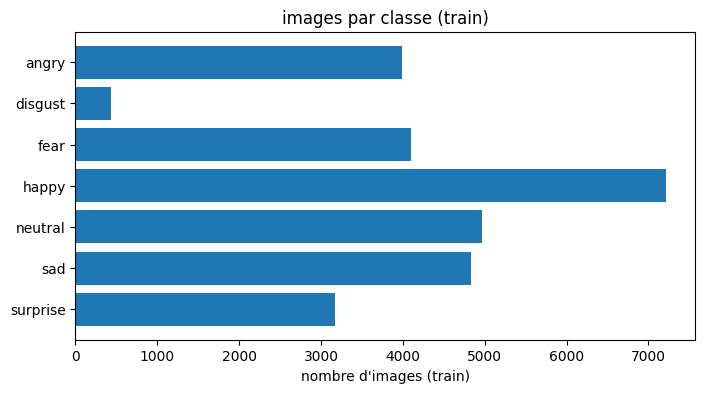

ratio max/min: 16.5


In [2]:
import matplotlib.pyplot as plt

nombres_train = []  # nb d'images train par classe, dans l'ordre de CLASS_NAMES

for split in ["train", "test"]:
    total = 0
    for classe in CLASS_NAMES:
        n = len(list((DATA_DIR / split / classe).glob("*.jpg")))
        total += n
        print(split, classe, n)
        if split == "train":
            nombres_train.append(n)
    print(split, "total:", total)
    print()

plt.figure(figsize=(8, 4))
plt.barh(CLASS_NAMES, nombres_train)
plt.gca().invert_yaxis()
plt.xlabel("nombre d'images (train)")
plt.title("images par classe (train)")
plt.show()

print("ratio max/min:", round(max(nombres_train) / min(nombres_train), 1))

### 1b - Exemples et vérification du format

On affiche 5 images par classe pour voir à quoi ça ressemble. Ensuite on vérifie sur toutes les images (train + test) que c'est bien du 48x48, en gris (mode "L" dans PIL) et en .jpg. Si une image avait une autre taille le Flatten planterait.

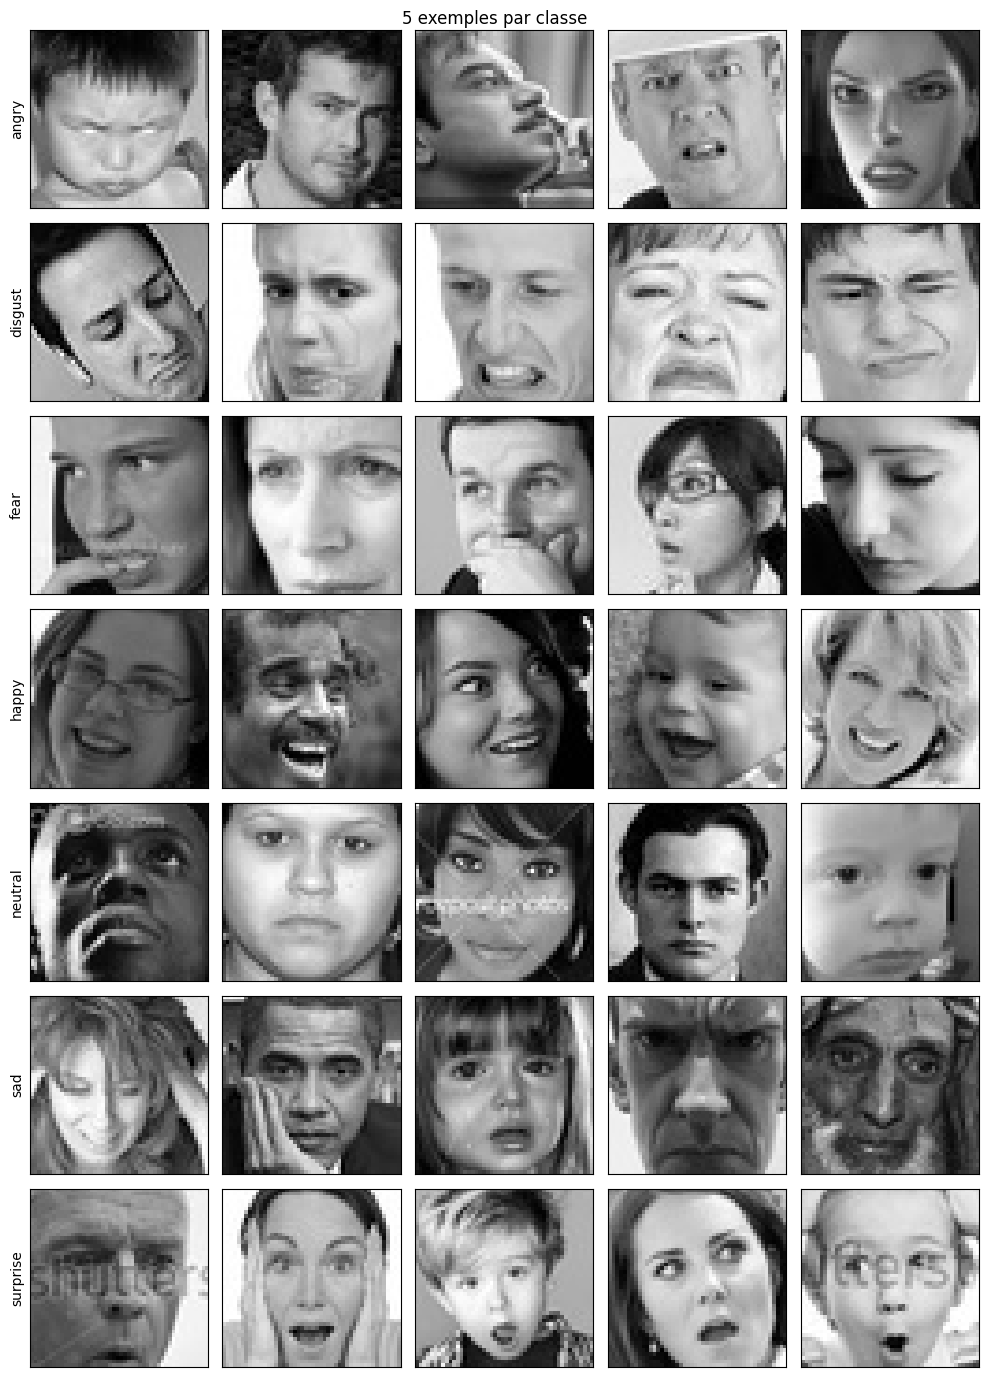

images vérifiées: 35874
tailles: {(48, 48): 35874}
modes: {'L': 35874}
extensions: {'.jpg': 35874}
problèmes: 0


In [3]:
from collections import Counter

N_EXEMPLES = 5

fig, axes = plt.subplots(len(CLASS_NAMES), N_EXEMPLES, figsize=(10, 14))
for ligne, classe in enumerate(CLASS_NAMES):
    fichiers = sorted((DATA_DIR / "train" / classe).glob("*.jpg"))[:N_EXEMPLES]
    for col, chemin in enumerate(fichiers):
        with Image.open(chemin) as img:
            axes[ligne, col].imshow(img, cmap="gray")
        axes[ligne, col].set_xticks([])
        axes[ligne, col].set_yticks([])
    axes[ligne, 0].set_ylabel(classe)
plt.suptitle("5 exemples par classe")
plt.tight_layout()
plt.show()
# extension = format des fichiers
# mode = type de l'image (ex: "L" pour grayscale)
# probl
# vérif du format sur toutes les images
tailles = Counter() # counter c'est pour compter combien d'images ont chaque taille
modes = Counter() # counter c'est pour compter combien d'images ont chaque mode
extensions = Counter() # counter c'est pour compter combien d'images ont chaque extension
modes = Counter() # counter c'est pour compter combien d'images ont chaque mode
problemes = []
n_images = 0
for split in ["train", "test"]:  # lancer 2 fois la boucle, 1 pour l'entraînement et 1 pour le test
    for classe in CLASS_NAMES:
        for chemin in sorted((DATA_DIR / split / classe).iterdir()): # chemin du dossier data/<split>/<classe> genre data/fer2013/train/angry et parcours ses éléments
            n_images += 1
            try:
                with Image.open(chemin) as img:
                    taille = img.size
                    mode = img.mode
            except OSError:
                problemes.append(chemin)
                continue
            ext = chemin.suffix.lower()
            tailles[taille] += 1
            modes[mode] += 1
            extensions[ext] += 1
            if taille != IMAGE_SIZE or mode != "L" or ext != ".jpg":
                problemes.append(chemin)

print("images vérifiées:", n_images)
print("tailles:", dict(tailles))
print("modes:", dict(modes))
print("extensions:", dict(extensions))
print("problèmes:", len(problemes))
for p in problemes[:20]:
    print(p)

### 1c - Préparation : train / validation / test

On crée les datasets avec `image_dataset_from_directory` :
- pas de redimensionnement, les images font déjà 48x48 (vu en 1b), donc une image = (48, 48, 1)
- normalisation : on divise les pixels par 255 pour passer de [0, 255] à [0, 1], l'entraînement est plus stable avec des petites valeurs
- labels : le nom du dossier donne la classe, encodée en one-hot avec `label_mode="categorical"` (happy = [0,0,0,1,0,0,0]). C'est ce qu'il faut pour softmax + categorical_crossentropy
- validation : 20% du dossier train (5 739 images). Elle sert à suivre l'entraînement et à choisir les modèles, le modèle n'apprend jamais dessus
- test : le dossier test (7 177 images). On n'y touche pas avant la toute fin (partie 6), sinon le score final serait faussé

`cache()` seulement sur val et test, sur train ça bloquerait l'ordre des images alors qu'on veut qu'il change à chaque époque.

In [4]:
import tensorflow as tf

BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    label_mode="categorical",
    class_names=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=SEED,  # même découpage train/val à chaque fois
)

test_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    label_mode="categorical",
    class_names=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("train:", len(train_ds.file_paths))
print("val:", len(val_ds.file_paths))
print("test:", len(test_ds.file_paths))


def normaliser(images, labels):
    return images / 255.0, labels


train_ds = train_ds.map(normaliser).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(normaliser).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(normaliser).cache().prefetch(tf.data.AUTOTUNE)
# map est utilisé pour appliquer la fonction de normalisation à chaque lot d'images
# prefetch permet de préparer les lots suivants pendant que le modèle s'entraîne sur le lot actuel, ce qui améliore les performances.
# cache permet de stocker les données en mémoire après la première lecture, ce qui accélère les accès ultérieurs.

# petit check sur un lot
images_batch, labels_batch = next(iter(train_ds))
print(images_batch.shape, labels_batch.shape)
print("pixels min/max:", float(images_batch.numpy().min()), float(images_batch.numpy().max()))

Found 28697 files belonging to 7 classes.
Using 22958 files for training.
Using 5739 files for validation.
Found 7177 files belonging to 7 classes.
train: 22958
val: 5739
test: 7177
(128, 48, 48, 1) (128, 7)
pixels min/max: 0.0 1.0


## Partie 2 - Baseline dense

Le modèle le plus simple possible, juste pour avoir un point de comparaison avec le CNN. On suit le schéma du sujet : Flatten, Dense 128 (ReLU), Dense 7 (softmax).

Flatten met les 48x48 = 2304 pixels dans un seul vecteur. Chaque neurone de la couche cachée fait une somme pondérée de ces pixels plus un biais, puis ReLU. En sortie softmax donne 7 probabilités qui font 1 au total, la classe prédite est la plus probable.

Le problème attendu : après Flatten le réseau ne sait plus quels pixels sont voisins, un visage un peu décalé devient un vecteur complètement différent. C'est ce que le CNN doit corriger.

Compilation : categorical_crossentropy (labels one-hot + softmax), Adam, et l'accuracy comme métrique.

In [5]:
from tensorflow.keras import layers

NUM_CLASSES = len(CLASS_NAMES)

baseline = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),  # (48, 48, 1)
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="baseline_dense",
)

baseline.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Comment il apprend, en gros : pour chaque lot de 128 images on fait la propagation avant (l'image traverse les couches jusqu'aux 7 probas), on calcule la loss, ici -log(proba donnée à la vraie classe), puis la rétropropagation calcule le gradient de la loss pour chaque poids. La descente de gradient (Adam, lr 0.001) bouge ensuite chaque poids dans le sens qui fait baisser la loss.

Il y a 295 943 paramètres à apprendre : 2304 x 128 + 128 pour la couche cachée, 128 x 7 + 7 pour la sortie.

### 2b - Entraînement de la baseline

20 époques fixes, sans early stopping ici pour bien voir le surapprentissage sur les courbes. val_loss et val_accuracy sont calculées sur la validation, sur laquelle le modèle n'apprend pas.

In [6]:
EPOCHS_BASELINE = 20

historique_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_BASELINE)
# fit est utilisé pour entraîner le modèle sur les données d'entraînement et évaluer sa performance sur les données de validation à chaque époque.

Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2667 - loss: 1.8047 - val_accuracy: 0.3096 - val_loss: 1.7336
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3208 - loss: 1.7202 - val_accuracy: 0.3236 - val_loss: 1.7223
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3406 - loss: 1.6857 - val_accuracy: 0.3231 - val_loss: 1.6814
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3496 - loss: 1.6657 - val_accuracy: 0.3434 - val_loss: 1.6617
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3500 - loss: 1.6609 - val_accuracy: 0.3506 - val_loss: 1.6498
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3553 - loss: 1.6462 - val_accuracy: 0.3492 - val_loss: 1.6441
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3629 - loss: 1.6334 - val_accuracy: 0.3495 - val_loss: 1.6623
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3677 - loss: 1.6223 - val_accuracy: 0

### 2c - Courbes et score

Pour savoir si le score est bon on le compare au hasard (1/7, environ 14%) et à un modèle qui répondrait toujours happy, la classe la plus fréquente (environ 25%).

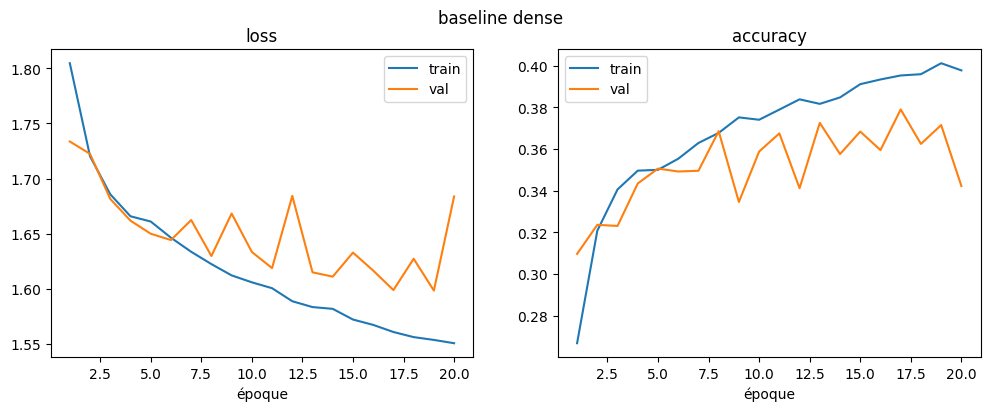

accuracy val baseline: 34.2 %
hasard: 14.3 %
toujours happy : 24.4 %


In [7]:
import numpy as np

h = historique_baseline.history
epoques = range(1, len(h["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epoques, h["loss"], label="train")
ax1.plot(epoques, h["val_loss"], label="val")
ax1.set_title("loss")
ax1.set_xlabel("époque")
ax1.legend()
ax2.plot(epoques, h["accuracy"], label="train")
ax2.plot(epoques, h["val_accuracy"], label="val")
ax2.set_title("accuracy")
ax2.set_xlabel("époque")
ax2.legend()
plt.suptitle("baseline dense")
plt.show()

perte_val, accuracy_val = baseline.evaluate(val_ds, verbose=0)

# nb d'images par classe dans la val, pour le repère "toujours la même classe"
comptes = np.zeros(NUM_CLASSES)
for images, labels in val_ds:
    comptes += labels.numpy().sum(axis=0)

print("accuracy val baseline:", round(accuracy_val * 100, 1), "%")
print("hasard:", round(100 / NUM_CLASSES, 1), "%")
print("toujours", CLASS_NAMES[int(comptes.argmax())], ":", round(comptes.max() / comptes.sum() * 100, 1), "%")

### 2d - Sortie pour une image

Les 7 probabilités données par la baseline pour une image de validation.

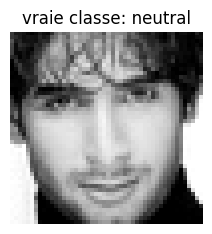

angry 0.02
disgust 0.0
fear 0.03
happy 0.3
neutral 0.62
sad 0.03
surprise 0.01
somme: 1.0
prédit: neutral / vrai: neutral


In [8]:
images_val, labels_val = next(iter(val_ds))

probabilites = baseline.predict(images_val[:1], verbose=0)[0] # prédictions pour la première image du lot de validation
vraie_classe = CLASS_NAMES[int(labels_val[0].numpy().argmax())]
classe_predite = CLASS_NAMES[int(probabilites.argmax())]

plt.figure(figsize=(2.5, 2.5))
plt.imshow(images_val[0], cmap="gray", vmin=0, vmax=1)
plt.title("vraie classe: " + vraie_classe)
plt.axis("off")
plt.show()

for classe, p in zip(CLASS_NAMES, probabilites):
    print(classe, round(float(p), 2))
print("somme:", round(float(probabilites.sum()), 2))
print("prédit:", classe_predite, "/ vrai:", vraie_classe)

## Partie 3 - CNN

On part du schéma du sujet : Conv2D + ReLU, MaxPooling, Conv2D + ReLU, MaxPooling, Flatten, Dense, softmax.

Les filtres (5x5 pour la première convolution, 3x3 pour la deuxième) glissent sur l'image et détectent des petits motifs (bords, coins) n'importe où dans l'image, ce que la baseline ne savait pas faire. Le MaxPooling garde le max de chaque carré 2x2 : la taille est divisée par 2 et le modèle est moins sensible à un petit décalage. Le 2e bloc combine les motifs simples en motifs plus grands (un oeil, une bouche).

Même compilation que la baseline pour pouvoir comparer.

In [9]:
# on remet la seed avant de créer le modèle, pour partir des mêmes poids que les expériences de la partie 6
keras.utils.set_random_seed(SEED)

cnn = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5, activation="relu"),  # (44, 44, 32)
        layers.MaxPooling2D(2),  # (22, 22, 32)
        layers.Conv2D(64, 3, activation="relu"),  # (20, 20, 64)
        layers.MaxPooling2D(2),  # (10, 10, 64)
        layers.Flatten(),  # 6400
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="cnn_base",
)

cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "cnn_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 44, 44, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │        44,807 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,135 (250.53 KB)

 Trainable params: 64,135 (250.53 KB)

 Non-trainable params: 0 (0.00 B)

### Dimensions et paramètres couche par couche

Stride 1 et padding "valid" (les valeurs par défaut) : on n'ajoute pas de zéros autour, donc la sortie rétrécit. Avec le kernel 5x5 de la première convolution on perd 4 pixels (48 - 5 + 1 = 44), avec le 3x3 de la deuxième on en perd 2 (22 - 3 + 1 = 20). Avec padding "same" on garderait la taille. Le pooling 2x2 divise par 2.

Pourquoi 5x5 seulement au début : sur l'image d'entrée il n'y a qu'un canal, donc un filtre plus large coûte peu (832 paramètres) et voit un morceau de visage plus grand dès la première couche. Ensuite il y a 32 canaux, un 5x5 coûterait presque 3 fois plus qu'un 3x3, donc on reste en 3x3.

Paramètres d'une conv = (hauteur x largeur du filtre x nb de canaux en entrée + 1 biais) x nb de filtres. Les mêmes poids servent partout dans l'image, d'où beaucoup moins de paramètres que la baseline.

| Couche | Sortie | Paramètres |
|---|---|---:|
| Entrée | (48, 48, 1) | 0 |
| Conv2D(32, 5) + ReLU | (44, 44, 32) | (5x5x1 + 1) x 32 = 832 |
| MaxPooling2D(2) | (22, 22, 32) | 0 |
| Conv2D(64, 3) + ReLU | (20, 20, 64) | (3x3x32 + 1) x 64 = 18 496 |
| MaxPooling2D(2) | (10, 10, 64) | 0 |
| Flatten | (6400,) | 0 |
| Dense(7) + softmax | (7,) | 6400 x 7 + 7 = 44 807 |
| Total | | 64 135 |

Pourquoi cette architecture - c'est celle du sujet, simple à comprendre, et 2 blocs suffisent pour du 48x48 (on finit en 10x10). On double les filtres (32 puis 64) quand l'image rétrécit. Elle a 4,6 fois moins de paramètres que la baseline (64 135 contre 295 943). Les variantes (plus de couches, dropout...) sont testées en partie 6.

## Partie 4 - Entraînement du CNN

Nos choix :
- loss : categorical_crossentropy, parce qu'il y a une seule classe par image parmi 7, en one-hot, avec softmax en sortie. Elle devient très grande quand le modèle se trompe en étant sûr de lui.
- optimiseur : Adam avec le learning rate par défaut (0.001). Il marche bien sans réglage, et la val_loss baisse dès le début (voir 4b), donc pas de raison de changer cette valeur de départ. En partie 6 on teste de le faire baisser en cours d'entraînement (E0).
- batch size : 128. Ça fait 180 mises à jour par époque (22 958 images / 128, le dernier lot n'a que 46 images) et ça passe largement en mémoire. Sur GPU un lot plus gros va plus vite, et avec des lots plus petits chaque mise à jour serait plus bruitée.
- époques : 30 max avec early stopping (patience 6) sur val_loss. On ne sait pas à l'avance combien il en faut, c'est la validation qui décide. On a pris une patience de 6 plutôt que 3 : la val_loss bouge un peu d'une époque à l'autre, et avec 3 on risque de s'arrêter sur un simple creux alors que le modèle peut encore progresser (on le soupçonnait pour E4). En partie 6 le learning rate baisse quand la val_loss stagne, il faut aussi laisser quelques époques au modèle pour en profiter.
- métriques : l'accuracy pendant l'entraînement, mais vu le déséquilibre on regarde aussi la matrice de confusion et le rappel par classe en partie 5 (un modèle peut avoir une accuracy correcte sans jamais trouver disgust).

On surveille val_loss plutôt que val_accuracy pour l'arrêt car elle bouge plus finement d'une époque à l'autre.

### 4a - Entraînement avec early stopping

Si val_loss ne s'améliore plus pendant 6 époques on arrête, et on reprend les poids de la meilleure époque (avant que le modèle commence à apprendre par coeur).

In [10]:
EPOCHS_CNN = 30

arret_automatique = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

historique_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_CNN, callbacks=[arret_automatique])

perte_val_cnn, accuracy_val_cnn = cnn.evaluate(val_ds, verbose=0)
print("accuracy val CNN:", round(accuracy_val_cnn * 100, 1), "%")
print("accuracy val baseline:", round(accuracy_val * 100, 1), "%")

Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.3294 - loss: 1.6935 - val_accuracy: 0.3840 - val_loss: 1.5923
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4215 - loss: 1.5229 - val_accuracy: 0.4414 - val_loss: 1.4736
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4530 - loss: 1.4355 - val_accuracy: 0.4546 - val_loss: 1.4292
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4829 - loss: 1.3702 - val_accuracy: 0.4677 - val_loss: 1.4017
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5065 - loss: 1.3172 - val_accuracy: 0.4720 - val_loss: 1.3918
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5215 - loss: 1.2734 - val_accuracy: 0.4928 - val_loss: 1.3526
Epoch 7/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5385 - loss: 1.2347 - val_accuracy: 0.4987 - val_loss: 1.3446
Epoch 8/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5534 - loss: 1.1932 - val_accuracy: 

### 4b - Courbes du CNN

Même graphique qu'en 2c, avec en pointillés la meilleure époque (celle gardée par l'early stopping). On le met dans une fonction parce qu'on le réutilise en partie 6.

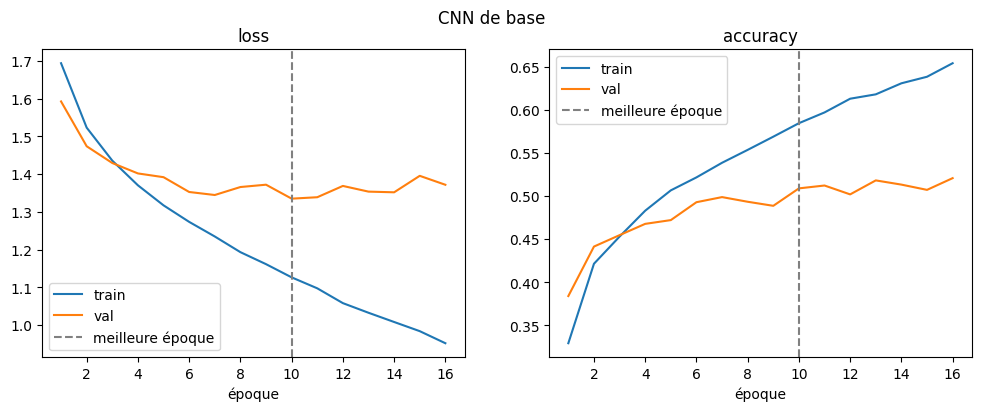

époques faites: 16 / meilleure: 10
meilleure époque: acc train 58.4 acc val 50.9 val_loss 1.335
dernière époque: acc train 65.4 acc val 52.1 val_loss 1.372


In [11]:
def tracer_courbes(historique, titre):
    h = historique.history
    epoques = range(1, len(h["loss"]) + 1)
    meilleure = int(np.argmin(h["val_loss"])) + 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epoques, h["loss"], label="train")
    ax1.plot(epoques, h["val_loss"], label="val")
    ax1.set_title("loss")
    ax2.plot(epoques, h["accuracy"], label="train")
    ax2.plot(epoques, h["val_accuracy"], label="val")
    ax2.set_title("accuracy")
    for ax in [ax1, ax2]:
        ax.axvline(meilleure, color="gray", linestyle="--", label="meilleure époque")
        ax.set_xlabel("époque")
        ax.legend()
    plt.suptitle(titre)
    plt.show()


tracer_courbes(historique_cnn, "CNN de base")

h = historique_cnn.history
m = int(np.argmin(h["val_loss"]))  # indice de la meilleure époque (0 = la 1ère)
print("époques faites:", len(h["loss"]), "/ meilleure:", m + 1)
print("meilleure époque: acc train", round(h["accuracy"][m] * 100, 1), "acc val", round(h["val_accuracy"][m] * 100, 1), "val_loss", round(h["val_loss"][m], 3))
print("dernière époque: acc train", round(h["accuracy"][-1] * 100, 1), "acc val", round(h["val_accuracy"][-1] * 100, 1), "val_loss", round(h["val_loss"][-1], 3))

Au début les deux loss baissent ensemble, puis elles se séparent : la loss train continue de baisser alors que la val_loss stagne puis remonte. Pour l'accuracy c'est pareil, celle du train continue de monter alors que celle de la val plafonne.

C'est du surapprentissage : à partir de la meilleure époque (la ligne en pointillés), le modèle commence à apprendre les images de train par coeur. L'early stopping s'arrête 6 époques plus tard et remet les poids de la meilleure époque. La cellule au-dessus affiche la meilleure époque et l'écart train/val de cette exécution. On essaie de réduire ce surapprentissage en partie 6 (dropout, augmentation).

## Partie 5 - Évaluation du CNN

Tout se fait sur la validation, le test est gardé pour la fin.

### 5a - Matrice de confusion et rappel par classe

Ligne = vraie classe, colonne = classe prédite, la diagonale = les bonnes réponses. Le rappel d'une classe c'est bonnes réponses / nombre d'images de la classe. Avec le déséquilibre c'est plus parlant que l'accuracy.

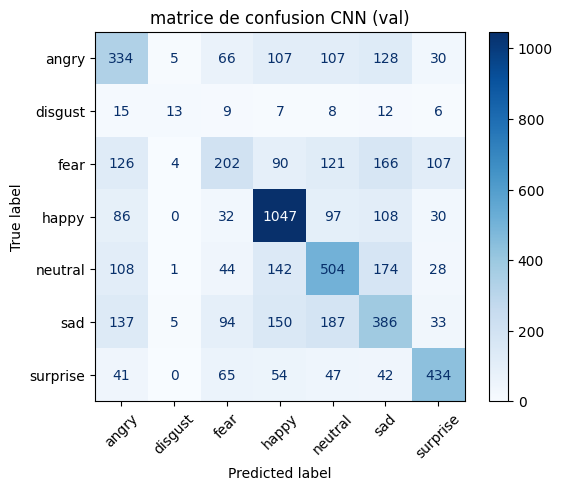

angry rappel: 43.0 % (334/777)
disgust rappel: 18.6 % (13/70)
fear rappel: 24.8 % (202/816)
happy rappel: 74.8 % (1047/1400)
neutral rappel: 50.3 % (504/1001)
sad rappel: 38.9 % (386/992)
surprise rappel: 63.5 % (434/683)


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# une seule boucle sur la val pour garder images, labels et prédictions dans le même ordre
images_lots = []
labels_lots = []
probabilites_lots = []
for images, labels in val_ds:
    images_lots.append(images.numpy())
    labels_lots.append(labels.numpy())
    probabilites_lots.append(cnn.predict_on_batch(images))
labels_onehot = np.concatenate(labels_lots)
probabilites_cnn = np.concatenate(probabilites_lots)

vraies_classes = labels_onehot.argmax(axis=1)
classes_predites = probabilites_cnn.argmax(axis=1)

matrice = confusion_matrix(vraies_classes, classes_predites)
ConfusionMatrixDisplay(matrice, display_labels=CLASS_NAMES).plot(cmap="Blues", xticks_rotation=45)
plt.title("matrice de confusion CNN (val)")
plt.show()

for i, classe in enumerate(CLASS_NAMES):
    bons = matrice[i, i]
    total = matrice[i].sum()
    print(classe, "rappel:", round(bons / total * 100, 1), "%", f"({bons}/{total})")

### 5b - Courbes ROC

Une courbe par classe (la classe contre toutes les autres). Plus l'AUC est proche de 1 mieux la classe est séparée, 0.5 c'est le hasard.

Attention, l'AUC regarde si les probas sont plus hautes pour les bonnes images, pas si la prédiction finale est juste. disgust peut avoir une bonne AUC et un mauvais rappel, donc on lit ça avec la matrice.

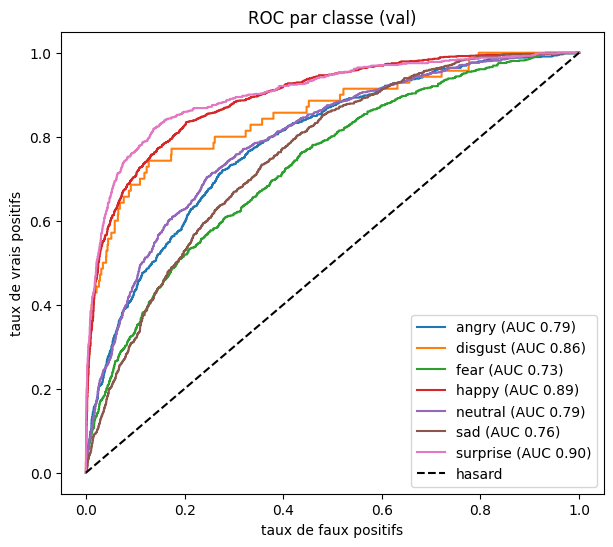

In [13]:
from sklearn.metrics import auc, roc_curve

plt.figure(figsize=(7, 6))
for i, classe in enumerate(CLASS_NAMES):
    fpr, tpr, seuils = roc_curve(labels_onehot[:, i], probabilites_cnn[:, i])
    plt.plot(fpr, tpr, label=f"{classe} (AUC {auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="hasard")
plt.xlabel("taux de faux positifs")
plt.ylabel("taux de vrais positifs")
plt.title("ROC par classe (val)")
plt.legend()
plt.show()

### 5c - Classes les plus confondues et les plus difficiles

On prend toutes les cases hors diagonale de la matrice et on les trie. On donne aussi le % par rapport à la vraie classe, car les classes n'ont pas la même taille (50 erreurs c'est énorme pour disgust qui a 70 images en val, pas pour happy).

In [14]:
confusions = []
for vraie in range(NUM_CLASSES):
    for predite in range(NUM_CLASSES):
        if vraie != predite:
            confusions.append((matrice[vraie, predite], vraie, predite))
confusions.sort(reverse=True)

print("les 5 confusions les plus fréquentes (vraie / prédite):")
for nombre, vraie, predite in confusions[:5]:
    pourcent = nombre / matrice[vraie].sum() * 100
    print(CLASS_NAMES[vraie], "/", CLASS_NAMES[predite], ":", nombre, "images", f"({pourcent:.1f}% des {CLASS_NAMES[vraie]})")

print()
print("classes de la plus dure à la plus facile:")
rappels = matrice.diagonal() / matrice.sum(axis=1)
for i in np.argsort(rappels):
    print(CLASS_NAMES[i], round(rappels[i] * 100, 1), "%")

les 5 confusions les plus fréquentes (vraie / prédite):
sad / neutral : 187 images (18.9% des sad)
neutral / sad : 174 images (17.4% des neutral)
fear / sad : 166 images (20.3% des fear)
sad / happy : 150 images (15.1% des sad)
neutral / happy : 142 images (14.2% des neutral)

classes de la plus dure à la plus facile:
disgust 18.6 %
fear 24.8 %
sad 38.9 %
angry 43.0 %
neutral 50.3 %
surprise 63.5 %
happy 74.8 %


happy et surprise sont parmi les mieux reconnues : le sourire pour l'une, la bouche ouverte et les yeux grands ouverts pour l'autre, ça se voit même en 48x48. happy a aussi le plus d'images d'entraînement.

Les plus grosses confusions passent presque toutes par sad et neutral : sad prise pour neutral, neutral prise pour sad, fear prise pour sad, et sad ou neutral prises pour happy. Un visage triste, neutre ou inquiet a souvent la bouche fermée, la différence se joue à quelques pixels autour des sourcils et des coins de la bouche.

Les classes les plus dures sont disgust et fear, puis sad et angry :
- disgust : surtout un problème de quantité, environ 16 fois moins d'images en train que happy. Le modèle la voit rarement et se tromper dessus coûte peu à l'accuracy.
- fear : elle n'a pas de signe à elle. Elle est prise pour sad, angry, neutral ou surprise (yeux et bouche ouverts).
- sad et angry : souvent confondues avec neutral, sans doute parce que des sourcils froncés ou des coins de bouche baissés se voient mal à cette résolution.

Autre cause probable, qu'on n'a pas mesurée : des étiquettes fausses dans FER2013. Les images viennent du web et certaines expressions sont ambiguës même pour nous (voir 5d).

Les nombres exacts sont affichés au-dessus. Ils bougent un peu d'une exécution à l'autre, mais ces tendances restent les mêmes.

### 5d - Exemples : image, vraie classe, prédiction, proba

4 images bien classées (en vert) et les 8 erreurs où le modèle était le plus sûr de lui (en rouge), ce sont les plus intéressantes à regarder.

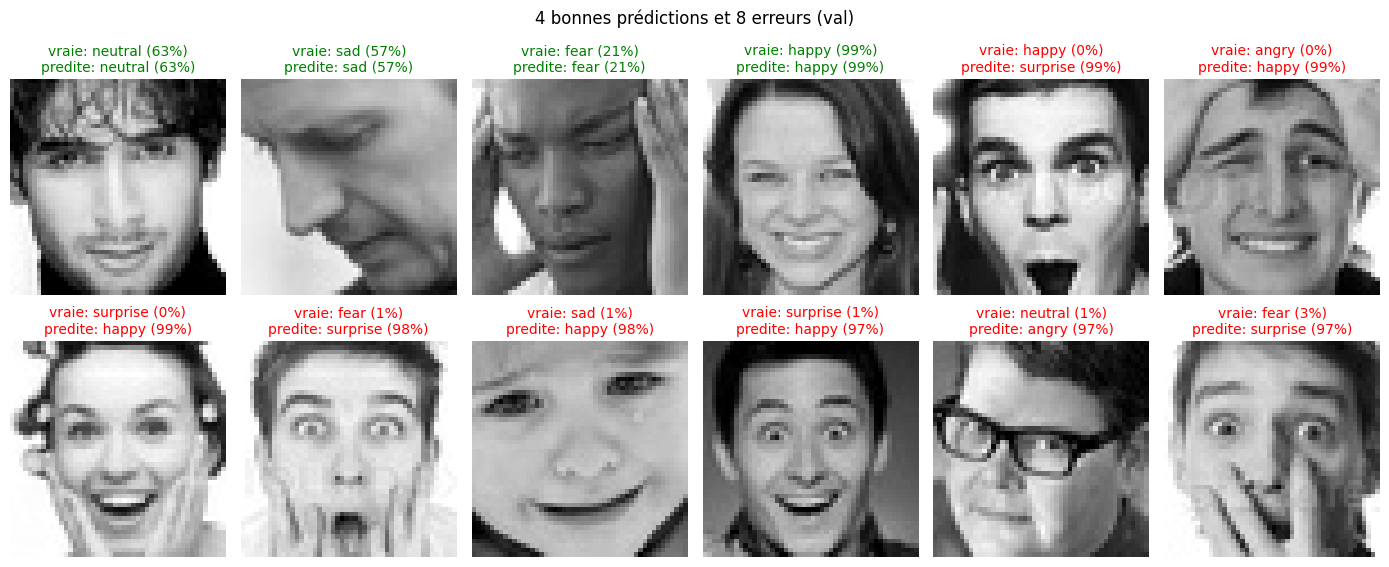

In [15]:
images_val_toutes = np.concatenate(images_lots)

bonnes = np.where(classes_predites == vraies_classes)[0]
fausses = np.where(classes_predites != vraies_classes)[0]

# on trie les erreurs par proba de la classe prédite, de la plus haute à la plus basse
confiance = probabilites_cnn[fausses].max(axis=1)
ordre = np.argsort(-confiance)
fausses_choisies = fausses[ordre[:8]]
exemples = list(bonnes[:4]) + list(fausses_choisies)

fig, axes = plt.subplots(2, 6, figsize=(14, 6))
for ax, n in zip(axes.flat, exemples):
    vraie = vraies_classes[n]
    predite = classes_predites[n]
    if vraie == predite:
        couleur = "green"
    else:
        couleur = "red"
    ax.imshow(images_val_toutes[n], cmap="gray", vmin=0, vmax=1)
    titre = f"vraie: {CLASS_NAMES[vraie]} ({probabilites_cnn[n, vraie]:.0%})\npredite: {CLASS_NAMES[predite]} ({probabilites_cnn[n, predite]:.0%})"
    ax.set_title(titre, color=couleur, fontsize=10)
    ax.axis("off")
plt.suptitle("4 bonnes prédictions et 8 erreurs (val)")
plt.tight_layout()
plt.show()

Sur les erreurs affichées, le modèle met presque toute la probabilité sur la mauvaise classe et presque rien sur la vraie. Les images changent un peu d'une exécution à l'autre, mais on retrouve à chaque fois les mêmes types d'erreurs :
- des expressions qui se ressemblent : fear prise pour surprise (yeux écarquillés, bouche ouverte), fear ou angry prise pour une autre classe quand la personne crie, neutral prise pour surprise quand la bouche est ouverte (bâillement) ;
- des étiquettes qui ont l'air fausses : une personne qui sourit étiquetée neutral ou surprise et prédite happy, la prédiction a l'air plus juste que le label ;
- des images difficiles : visage tout petit dans l'image, tête penchée, yeux plissés.

Le modèle a l'air de se baser surtout sur la bouche et l'ouverture des yeux, moins sur les sourcils. Et les étiquettes douteuses limitent sûrement le score max qu'on peut avoir sur FER2013.

## Partie 6 - Expériences

La référence c'est le CNN de la partie 4 (cnn_base). Chaque expérience part du dernier modèle gardé et change une seule chose, pour savoir d'où vient l'effet. Le reste ne bouge pas : même découpage, seed remise à 42 avant chaque modèle, Adam lr 0.001, batch 128, 20 époques fixes pour chaque expérience (on garde les poids de la meilleure époque). Seul cnn_base garde l'early stopping de la partie 4. E0 teste un learning rate qui baisse pendant l'entraînement (ReduceLROnPlateau). Comme chaque expérience part de la précédente, toutes les expériences suivantes gardent ce réglage (baisse_lr=True) : sinon on comparerait des modèles entraînés de deux façons différentes. Tout est mesuré sur la validation.

Pour chaque modèle on note l'accuracy et la loss de val, la meilleure époque, l'écart d'accuracy train - val (pour le surapprentissage) et le rappel de disgust (la classe la plus rare).

| | Changement | Pourquoi on essaie |
|---|---|---|
| E0 | learning rate qui baisse pendant l'entraînement (ReduceLROnPlateau) | des pas plus petits quand la val_loss ne baisse plus |
| E1 | deux couches Dense(128) et Dense(64) + ReLU avant la sortie (la figure 2 du sujet en a une) | combiner les motifs trouvés par les convolutions avant de décider |
| E1 bis | BatchNormalization après chaque convolution | des valeurs stables entre les couches, entraînement plus régulier |
| E2 | Dropout(0.3) avant la Dense(128) | le modèle surapprend vite (4b) |
| E3 | 3e et 4e blocs, Conv2D(128) puis Conv2D(256), + MaxPooling | motifs plus grands, et moins de valeurs en entrée de la Dense |
| E4 | data augmentation (miroir, petite rotation, petit zoom, flou léger) | le modèle voit des variantes à chaque époque, il apprend moins par coeur |
| E5 | E4 + class_weight | une erreur sur disgust coûte plus cher, son rappel devrait monter |

Règle fixée avant de voir les résultats : on garde un changement s'il améliore l'accuracy de val. Si l'écart est de moins d'un point, on regarde la val_loss et l'écart train/val. Le modèle final est celui qui a la meilleure accuracy de val, c'est le code qui le choisit en 6h.

Les lectures décrivent notre exécution de référence du 8 octobre 2026 au soir (Google Colab, GPU T4), celle dont les sorties sont enregistrées dans ce notebook.

### 6a - Fonctions pour les expériences

`entrainer` compile et entraîne un modèle avec les mêmes réglages qu'en partie 4, mais sur un nombre d'époques fixe (epoques=20 par défaut) : comme ça tous les modèles ont le même temps d'entraînement et aucun n'est arrêté trop tôt. À la fin on reprend quand même les poids de la meilleure époque (plus petite val_loss). Avec epoques=None on retrouve l'early stopping de la partie 4. Avec baisse_lr=True il ajoute la baisse du learning rate testée en E0. `mesurer` calcule les scores sur la validation et ajoute une ligne dans `resultats` (pour le tableau de la fin). On commence par mesurer cnn_base.

In [16]:
resultats = []
predictions = {}  # classes prédites sur la validation par chaque modèle, pour le tableau 6g
NUMERO_DISGUST = CLASS_NAMES.index("disgust")


def entrainer(modele, poids_classes=None, baisse_lr=False, epoques=20):
    modele.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    if epoques is None:
        # epoques=None : early stopping comme en partie 4 (30 époques max, patience 6)
        epoques = EPOCHS_CNN
        # un nouvel arrêt automatique par modèle : si on réutilise celui de 4a, il garde la meilleure val_loss du modèle d'avant
        callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)]
    else:
        # nombre d'époques fixe (20 par défaut). Avec patience = epoques l'arrêt ne se déclenche jamais,
        # il sert seulement à reprendre les poids de la meilleure époque à la fin
        callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=epoques, restore_best_weights=True)]
    if baisse_lr:
        # learning rate divisé par 2 si la val_loss n'a pas baissé depuis 3 époques (E0)
        # pas en dessous de 0.00001, sinon le modèle n'apprend plus rien et s'arrête trop tôt
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=0.00001, verbose=1))
    return modele.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epoques,
        callbacks=callbacks,
        class_weight=poids_classes,
        verbose=2,  # 1 ligne par époque
    )


def mesurer(nom, changement, modele, historique):
    perte, accuracy = modele.evaluate(val_ds, verbose=0)

    # val_ds est en cache donc toujours dans le même ordre que vraies_classes (5a)
    predites = modele.predict(val_ds, verbose=0).argmax(axis=1)
    predictions[nom] = predites
    est_disgust = vraies_classes == NUMERO_DISGUST
    rappel_disgust = (predites[est_disgust] == NUMERO_DISGUST).mean()

    h = historique.history
    m = int(np.argmin(h["val_loss"]))
    ecart = h["accuracy"][m] - h["val_accuracy"][m]

    resultats.append([nom, changement, accuracy, perte, m + 1, len(h["loss"]), ecart, rappel_disgust])
    print(nom, "| acc", round(accuracy * 100, 1), "| loss", round(perte, 3), "| meilleure ép.", m + 1, "/", len(h["loss"]),
          "| écart", round(ecart * 100, 1), "| rappel disgust", round(rappel_disgust * 100, 1))


mesurer("cnn_base", "référence (partie 3)", cnn, historique_cnn)

cnn_base | acc 50.9 | loss 1.335 | meilleure ép. 10 / 16 | écart 7.6 | rappel disgust 18.6


### 6a bis - E0 : learning rate qui baisse (ReduceLROnPlateau)

Avant de toucher au modèle, on teste un changement dans l'entraînement. Avec cnn_base le learning rate d'Adam reste à 0.001 du début à la fin. Au début ces grands pas font baisser la loss vite. Près du minimum ils sont trop grands, le modèle saute autour sans s'y poser et la val_loss arrête de baisser.

Avec ReduceLROnPlateau le learning rate est divisé par 2 quand la val_loss n'a pas baissé depuis 3 époques (factor=0.5, patience=3), sans descendre sous 0.00001 (min_lr). On avait d'abord mis patience=1 : la val_loss remonte souvent un peu sur une seule époque sans que ce soit un vrai plateau, donc le learning rate était divisé trop souvent, il devenait presque nul et l'entraînement s'arrêtait trop tôt. Même modèle que cnn_base, entraîné sur 20 époques fixes comme toutes les expériences.

In [17]:
keras.utils.set_random_seed(SEED)

modele_e0 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5, activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e0_baisse_lr",
)
historique_e0 = entrainer(modele_e0, baisse_lr=True)  # nouveau : le learning rate baisse sur plateau
mesurer("e0_baisse_lr", "+ ReduceLROnPlateau", modele_e0, historique_e0)

# learning rate utilisé à chaque époque
for i, lr in enumerate(historique_e0.history["learning_rate"]):
    print("époque", i + 1, "learning rate", float(lr))

Epoch 1/20
180/180 - 6s - 34ms/step - accuracy: 0.3315 - loss: 1.6926 - val_accuracy: 0.3928 - val_loss: 1.5813 - learning_rate: 0.0010
Epoch 2/20
180/180 - 2s - 9ms/step - accuracy: 0.4238 - loss: 1.5220 - val_accuracy: 0.4292 - val_loss: 1.4962 - learning_rate: 0.0010
Epoch 3/20
180/180 - 2s - 9ms/step - accuracy: 0.4596 - loss: 1.4279 - val_accuracy: 0.4518 - val_loss: 1.4239 - learning_rate: 0.0010
Epoch 4/20
180/180 - 2s - 9ms/step - accuracy: 0.4892 - loss: 1.3568 - val_accuracy: 0.4752 - val_loss: 1.3914 - learning_rate: 0.0010
Epoch 5/20
180/180 - 2s - 9ms/step - accuracy: 0.5115 - loss: 1.3049 - val_accuracy: 0.4863 - val_loss: 1.3706 - learning_rate: 0.0010
Epoch 6/20
180/180 - 2s - 9ms/step - accuracy: 0.5382 - loss: 1.2456 - val_accuracy: 0.4983 - val_loss: 1.3579 - learning_rate: 0.0010
Epoch 7/20
180/180 - 2s - 9ms/step - accuracy: 0.5534 - loss: 1.2022 - val_accuracy: 0.4994 - val_loss: 1.3456 - learning_rate: 0.0010
Epoch 8/20
180/180 - 2s - 9ms/step - accuracy: 0.5692 

La baisse du learning rate ne donne pas de gain seule : l'accuracy et la val_loss restent au niveau de cnn_base. Les baisses arrivent tard, après la meilleure époque, quand le modèle a déjà commencé à surapprendre, et des pas plus petits ne font pas redescendre la val_loss.

D'après notre règle ce changement seul ne serait pas gardé. Les expériences suivantes l'utilisent quand même (baisse_lr=True) : ce choix avait été fait avant d'avoir le résultat, et on ne l'a pas mesuré séparément sur les modèles suivants. On le dit tel quel.

### 6b - E1 : deux couches Dense cachées (128 puis 64)

Dans cnn_base les 6400 valeurs vont directement aux 7 sorties. Avec des couches cachées entre les deux, le modèle peut combiner les motifs avant de décider (par exemple coins de la bouche relevés + yeux plissés). La figure 2 du sujet en a une. On en met deux, Dense(128) puis Dense(64), pour descendre par étapes de 6400 valeurs vers 7 au lieu de tout résumer d'un coup.

Le nombre de paramètres passe de 64 135 à 847 367, presque tout dans la première couche (6400 x 128 + 128 = 819 328). La Dense(64) n'en ajoute que 8 256.

In [18]:
keras.utils.set_random_seed(SEED)

modele_e1 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5, activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),  # nouveau
        layers.Dense(64, activation="relu"),  # nouveau
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e1_dense128",
)
historique_e1 = entrainer(modele_e1, baisse_lr=True)
mesurer("e1_dense128", "+ Dense(128) + Dense(64)", modele_e1, historique_e1)

Epoch 1/20
180/180 - 8s - 44ms/step - accuracy: 0.3370 - loss: 1.6772 - val_accuracy: 0.4018 - val_loss: 1.5560 - learning_rate: 0.0010
Epoch 2/20
180/180 - 2s - 9ms/step - accuracy: 0.4369 - loss: 1.4692 - val_accuracy: 0.4452 - val_loss: 1.4430 - learning_rate: 0.0010
Epoch 3/20
180/180 - 2s - 9ms/step - accuracy: 0.4782 - loss: 1.3588 - val_accuracy: 0.4769 - val_loss: 1.3678 - learning_rate: 0.0010
Epoch 4/20
180/180 - 2s - 9ms/step - accuracy: 0.5195 - loss: 1.2667 - val_accuracy: 0.4896 - val_loss: 1.3498 - learning_rate: 0.0010
Epoch 5/20
180/180 - 2s - 9ms/step - accuracy: 0.5513 - loss: 1.1877 - val_accuracy: 0.5088 - val_loss: 1.3496 - learning_rate: 0.0010
Epoch 6/20
180/180 - 2s - 9ms/step - accuracy: 0.5801 - loss: 1.1134 - val_accuracy: 0.5067 - val_loss: 1.3260 - learning_rate: 0.0010
Epoch 7/20
180/180 - 2s - 9ms/step - accuracy: 0.6066 - loss: 1.0458 - val_accuracy: 0.5196 - val_loss: 1.3415 - learning_rate: 0.0010
Epoch 8/20
180/180 - 2s - 9ms/step - accuracy: 0.6427 

L'accuracy et la val_loss restent presque les mêmes que E0 (écart minuscule, ça peut venir du hasard). Par contre il surapprend plus vite : sa meilleure époque arrive plus tôt, puis la val_loss remonte pendant que l'accuracy train continue de monter. Logique avec 13 fois plus de paramètres pour les mêmes images. disgust est un peu mieux trouvé.

On garde : à accuracy presque égale la loss n'est pas moins bonne, et c'est proche du schéma de la figure 2 du sujet. Son surapprentissage c'est justement ce qu'on teste avec E2.

### 6b bis - E1 bis : batch normalization

On repart de E1. Après chaque convolution on ajoute une couche BatchNormalization. Elle recentre les valeurs de chaque carte sur le lot (moyenne 0, écart-type 1), puis apprend une échelle et un décalage.

Pourquoi : à chaque mise à jour des premières couches, les couches suivantes reçoivent des valeurs qui changent de plage et doivent se réadapter. Avec la batch normalization elles reçoivent des valeurs stables, donc l'entraînement est en général plus régulier. On la met tôt dans la série parce que ça comptera encore plus quand on ajoutera des blocs de convolution (E3).

L'ordre dans un bloc est convolution, batch normalization, ReLU, pooling. On ne l'ajoute qu'aux convolutions pour ne changer qu'une chose. En prédiction elle utilise des moyennes gardées pendant l'entraînement, pas celles du lot.

Le modèle passe de 847 367 à 847 751 paramètres (4 par filtre, dont 2 appris). Les expériences suivantes (E2 à E5) repartent de ce modèle, elles ont donc toutes la batch normalization.

In [19]:
keras.utils.set_random_seed(SEED)

modele_e1b = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5),
        layers.BatchNormalization(),  # nouveau, après chaque convolution et avant le ReLU
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e1b_batchnorm",
)
historique_e1b = entrainer(modele_e1b, baisse_lr=True)
mesurer("e1b_batchnorm", "+ BatchNormalization", modele_e1b, historique_e1b)

Epoch 1/20
180/180 - 12s - 68ms/step - accuracy: 0.3482 - loss: 1.7191 - val_accuracy: 0.2699 - val_loss: 1.8340 - learning_rate: 0.0010
Epoch 2/20
180/180 - 2s - 11ms/step - accuracy: 0.4430 - loss: 1.4488 - val_accuracy: 0.3760 - val_loss: 1.6316 - learning_rate: 0.0010
Epoch 3/20
180/180 - 2s - 11ms/step - accuracy: 0.4865 - loss: 1.3364 - val_accuracy: 0.4276 - val_loss: 1.4825 - learning_rate: 0.0010
Epoch 4/20
180/180 - 2s - 10ms/step - accuracy: 0.5138 - loss: 1.2686 - val_accuracy: 0.4375 - val_loss: 1.4627 - learning_rate: 0.0010
Epoch 5/20
180/180 - 2s - 10ms/step - accuracy: 0.5405 - loss: 1.2023 - val_accuracy: 0.4466 - val_loss: 1.4910 - learning_rate: 0.0010
Epoch 6/20
180/180 - 2s - 11ms/step - accuracy: 0.5625 - loss: 1.1465 - val_accuracy: 0.4656 - val_loss: 1.4517 - learning_rate: 0.0010
Epoch 7/20
180/180 - 2s - 10ms/step - accuracy: 0.5881 - loss: 1.0910 - val_accuracy: 0.4945 - val_loss: 1.3690 - learning_rate: 0.0010
Epoch 8/20
180/180 - 2s - 11ms/step - accuracy:

L'accuracy gagne plus d'un point par rapport à E1, donc d'après notre règle on garde la batch normalization. Mais ce n'est pas un gain propre : la val_loss est moins bonne, la courbe de val est en dents de scie, et l'écart train/val devient très grand (l'accuracy train monte beaucoup plus vite qu'avant). Le modèle apprend plus vite, y compris par coeur. Le dropout de E2 doit corriger ça.

### 6c - E2 : Dropout

Avec E1 la meilleure époque arrive tôt, et presque tous les paramètres sont dans la Dense(128) (819 328 sur 847 751). On ajoute un Dropout(0.3) juste avant. Pendant l'entraînement il met à 0 environ 30% des valeurs au hasard, différentes à chaque lot, donc le réseau ne peut pas compter sur quelques valeurs précises. En prédiction il est désactivé. Il n'ajoute pas de paramètre.

On a pris 0.3 plutôt que 0.5, la valeur la plus courante. Avec 0.5 on enlève la moitié de l'information à chaque lot, c'est beaucoup pour un petit modèle. On l'a vu avec l'augmentation (E4) : dropout 0.5 et augmentation ensemble, le modèle avait du mal à apprendre, son accuracy train passait sous celle de la val. Avec 0.3 on veut freiner le surapprentissage sans trop ralentir l'apprentissage.

In [20]:
keras.utils.set_random_seed(SEED)

modele_e2 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),  # nouveau, actif seulement pendant l'entraînement
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e2_dropout",
)
historique_e2 = entrainer(modele_e2, baisse_lr=True)
mesurer("e2_dropout", "+ Dropout(0.3)", modele_e2, historique_e2)

Epoch 1/20
180/180 - 11s - 63ms/step - accuracy: 0.3470 - loss: 1.7068 - val_accuracy: 0.2497 - val_loss: 1.8385 - learning_rate: 0.0010
Epoch 2/20
180/180 - 2s - 11ms/step - accuracy: 0.4363 - loss: 1.4671 - val_accuracy: 0.3562 - val_loss: 1.6325 - learning_rate: 0.0010
Epoch 3/20
180/180 - 2s - 11ms/step - accuracy: 0.4732 - loss: 1.3766 - val_accuracy: 0.4407 - val_loss: 1.4263 - learning_rate: 0.0010
Epoch 4/20
180/180 - 2s - 10ms/step - accuracy: 0.5056 - loss: 1.3066 - val_accuracy: 0.4260 - val_loss: 1.4546 - learning_rate: 0.0010
Epoch 5/20
180/180 - 2s - 11ms/step - accuracy: 0.5185 - loss: 1.2617 - val_accuracy: 0.4748 - val_loss: 1.3901 - learning_rate: 0.0010
Epoch 6/20
180/180 - 2s - 11ms/step - accuracy: 0.5406 - loss: 1.2154 - val_accuracy: 0.4773 - val_loss: 1.3602 - learning_rate: 0.0010
Epoch 7/20
180/180 - 2s - 11ms/step - accuracy: 0.5512 - loss: 1.1813 - val_accuracy: 0.5095 - val_loss: 1.2980 - learning_rate: 0.0010
Epoch 8/20
180/180 - 2s - 11ms/step - accuracy:

Gain par rapport à E1 bis (plus d'un point) et val_loss plus basse. La meilleure époque arrive plus tard et l'écart train/val diminue : le dropout freine bien l'apprentissage par coeur. Le surapprentissage n'a pas disparu, l'accuracy train reste au-dessus de celle de val. On garde.

### 6d - E3 : un 3e et un 4e bloc de convolution

Avec 2 blocs, chaque valeur de la dernière couche ne voit qu'un bout du visage. Deux blocs de plus combinent ces bouts en motifs plus grands (la bouche avec les joues, les sourcils avec les yeux). Ils réduisent aussi la taille avant Flatten : 1024 valeurs au lieu de 6400 en entrée de la Dense, donc moins de poids.

On ajoute Conv2D(128, 3) + MaxPooling2D(2), puis Conv2D(256, 3) + MaxPooling2D(2), en doublant les filtres à chaque bloc (32, 64, 128, 256). Chaque convolution est suivie de la batch normalization, comme depuis E1 bis. La Conv2D(256) est en padding same : elle garde la taille (4, 4), sinon il ne resterait qu'une seule valeur par carte après le pooling.

| Couche | Sortie | Paramètres |
|---|---|---:|
| après le 2e bloc | (10, 10, 64) | |
| Conv2D(128, 3) + ReLU | (8, 8, 128) | (3x3x64 + 1) x 128 = 73 856 |
| MaxPooling2D(2) | (4, 4, 128) | 0 |
| Conv2D(256, 3, same) + ReLU | (4, 4, 256) | (3x3x128 + 1) x 256 = 295 168 |
| MaxPooling2D(2) | (2, 2, 256) | 0 |
| Flatten | (1024,) | 0 |
| Dense(128) | (128,) | 1024 x 128 + 128 = 131 200 |
| Dense(64) | (64,) | 128 x 64 + 64 = 8 256 |
| BatchNormalization après les 4 convolutions | | 4 x (32 + 64 + 128 + 256) = 1 920 |
| Total du modèle | | 530 183 (847 751 pour E2) |

In [21]:
keras.utils.set_random_seed(SEED)

modele_e3 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.Conv2D(32, 5),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3),  # nouveau 3e bloc : (8, 8, 128)
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),  # (4, 4, 128)
        layers.Conv2D(256, 3, padding="same"),  # nouveau 4e bloc, same garde (4, 4)
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),  # (2, 2, 256)
        layers.Flatten(),  # 2 x 2 x 256 = 1024
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e3_4_blocs",
)
historique_e3 = entrainer(modele_e3, baisse_lr=True)
mesurer("e3_4_blocs", "+ blocs Conv2D(128) et Conv2D(256)", modele_e3, historique_e3)

Epoch 1/20
180/180 - 19s - 106ms/step - accuracy: 0.3746 - loss: 1.6036 - val_accuracy: 0.1762 - val_loss: 1.9027 - learning_rate: 0.0010
Epoch 2/20
180/180 - 2s - 13ms/step - accuracy: 0.4785 - loss: 1.3510 - val_accuracy: 0.3358 - val_loss: 1.7020 - learning_rate: 0.0010
Epoch 3/20
180/180 - 2s - 13ms/step - accuracy: 0.5378 - loss: 1.2183 - val_accuracy: 0.4924 - val_loss: 1.3167 - learning_rate: 0.0010
Epoch 4/20
180/180 - 2s - 13ms/step - accuracy: 0.5665 - loss: 1.1458 - val_accuracy: 0.5114 - val_loss: 1.3025 - learning_rate: 0.0010
Epoch 5/20
180/180 - 2s - 13ms/step - accuracy: 0.5960 - loss: 1.0667 - val_accuracy: 0.5060 - val_loss: 1.3197 - learning_rate: 0.0010
Epoch 6/20
180/180 - 2s - 13ms/step - accuracy: 0.6284 - loss: 0.9898 - val_accuracy: 0.4354 - val_loss: 1.5762 - learning_rate: 0.0010
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
180/180 - 2s - 13ms/step - accuracy: 0.6549 - loss: 0.9189 - val_accuracy: 0.4837 - val_loss: 

Ici le résultat est contre nous : l'accuracy mesurée baisse de plus de 2 points par rapport à E2 et la val_loss est moins bonne. La meilleure époque (plus petite val_loss) est la 4e, puis le modèle surapprend très fort : l'accuracy train dépasse 90 %. disgust n'est plus jamais prédit.

Point intéressant : pendant que la val_loss remonte, l'accuracy de val continue de monter et finit bien plus haut qu'à l'époque 4. Le modèle classe correctement de plus en plus d'images, mais il devient beaucoup trop sûr de lui sur celles qu'il rate, ce qui fait grimper la loss. Comme on garde les poids de la plus petite val_loss, c'est le modèle de l'époque 4 qui est mesuré.

D'après notre règle on ne devrait pas garder E3. E4 part quand même de E3 : la chaîne était écrite avant le run. On le dit tel quel. Ce modèle plus profond a surtout besoin d'être régularisé, et c'est justement ce que fait E4.

### 6e - E4 : data augmentation

E3 surapprend encore un peu (sa val_loss remonte après sa meilleure époque). Avec l'augmentation, le modèle ne voit jamais 2 fois exactement la même image. On ajoute 4 couches au début du modèle :
- RandomFlip("horizontal") : miroir gauche/droite, une expression reste la même dans un miroir (pas de haut/bas, il n'y a pas de visages à l'envers)
- RandomRotation(0.05) : rotation de 18° max (0.05 tour), comme une tête un peu penchée
- RandomZoom(0.1) : zoom avant ou arrière de 10% max
- RandomGaussianBlur : flou léger, plus ou moins fort selon l'image (noyau 3x3). Les photos de FER2013 n'ont pas toutes la même netteté, le modèle doit reconnaître l'expression même sur une image un peu floue. value_range=(0, 1) parce que nos pixels sont déjà divisés par 255

Ces couches ne marchent que pendant l'entraînement. En val, en test et pour la démo l'image n'est pas modifiée.

In [22]:
keras.utils.set_random_seed(SEED)

modele_e4 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        # nouveau : augmentation, seulement pendant l'entraînement
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomGaussianBlur(factor=0.5, kernel_size=3, sigma=1.0, value_range=(0, 1)),
        layers.Conv2D(32, 5),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e4_augmentation",
)
historique_e4 = entrainer(modele_e4, baisse_lr=True)
mesurer("e4_augmentation", "+ augmentation", modele_e4, historique_e4)

Epoch 1/20
180/180 - 14s - 77ms/step - accuracy: 0.3407 - loss: 1.6744 - val_accuracy: 0.2809 - val_loss: 1.8658 - learning_rate: 0.0010
Epoch 2/20
180/180 - 5s - 26ms/step - accuracy: 0.4293 - loss: 1.4616 - val_accuracy: 0.3806 - val_loss: 1.5706 - learning_rate: 0.0010
Epoch 3/20
180/180 - 5s - 26ms/step - accuracy: 0.4774 - loss: 1.3555 - val_accuracy: 0.4741 - val_loss: 1.3776 - learning_rate: 0.0010
Epoch 4/20
180/180 - 5s - 26ms/step - accuracy: 0.5035 - loss: 1.2921 - val_accuracy: 0.5091 - val_loss: 1.2770 - learning_rate: 0.0010
Epoch 5/20
180/180 - 5s - 26ms/step - accuracy: 0.5274 - loss: 1.2423 - val_accuracy: 0.4966 - val_loss: 1.3267 - learning_rate: 0.0010
Epoch 6/20
180/180 - 5s - 26ms/step - accuracy: 0.5330 - loss: 1.2209 - val_accuracy: 0.5090 - val_loss: 1.2919 - learning_rate: 0.0010
Epoch 7/20
180/180 - 5s - 27ms/step - accuracy: 0.5476 - loss: 1.1942 - val_accuracy: 0.5299 - val_loss: 1.2183 - learning_rate: 0.0010
Epoch 8/20
180/180 - 5s - 27ms/step - accuracy:

C'est le plus gros gain de toutes les expériences : l'accuracy de val passe au-dessus de 60 %, la val_loss est la plus basse, et l'écart train/val redevient petit. Les deux courbes montent ensemble et la val_loss baisse presque jusqu'à la fin (avec un gros creux à une époque). La meilleure époque est l'avant-dernière, donc le modèle progressait encore et gagnerait sans doute à tourner plus longtemps.

Avec l'augmentation, le modèle à 4 blocs de E3 ne peut plus apprendre les images par coeur : c'est ce qui lui manquait. Dans notre toute première exécution l'augmentation faisait perdre de l'accuracy, mais beaucoup de choses ont changé depuis (20 époques fixes, dropout 0.3, batch normalization, flou, architecture), on ne peut pas dire laquelle explique la différence.

On garde l'augmentation. E5 part de E4.

### 6f - E5 : poids par classe (class_weight)

Même avec E4, disgust reste une classe mal trouvée. Le modèle la voit 16 fois moins souvent que happy, donc ses erreurs dessus comptent peu dans la loss. Avec class_weight, l'erreur sur une image est multipliée par le poids de sa classe : poids = nb total d'images / (7 x nb d'images de la classe). Une classe moyenne a un poids autour de 1, une classe rare un poids plus grand.

Même modèle que E4, le dernier gardé (avec l'augmentation), on ajoute seulement les poids. Les poids sont calculés avec les comptes de 1a (tout le dossier train). La validation est tirée au hasard dedans, donc les proportions sont presque les mêmes.

In [23]:
total_images = sum(nombres_train)
poids_classes = {}
for i, nombre in enumerate(nombres_train):
    poids_classes[i] = total_images / (NUM_CLASSES * nombre)
    print(CLASS_NAMES[i], nombre, "images, poids", round(poids_classes[i], 2))

keras.utils.set_random_seed(SEED)
modele_e5 = keras.Sequential(
    [
        keras.Input(shape=IMAGE_SIZE + (1,)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomGaussianBlur(factor=0.5, kernel_size=3, sigma=1.0, value_range=(0, 1)),
        layers.Conv2D(32, 5),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="e5_poids_classes",
)
historique_e5 = entrainer(modele_e5, poids_classes, baisse_lr=True)  # nouveau : poids par classe
mesurer("e5_poids_classes", "E4 + class_weight", modele_e5, historique_e5)

# rappel de chaque classe avec E4 et avec E5 : la seule différence entre les deux c'est class_weight
predites_e4 = predictions["e4_augmentation"]
predites_e5 = predictions["e5_poids_classes"]
for i, classe in enumerate(CLASS_NAMES):
    est_classe = vraies_classes == i
    r4 = (predites_e4[est_classe] == i).mean()
    r5 = (predites_e5[est_classe] == i).mean()
    print(classe, "E4:", round(r4 * 100, 1), "E5:", round(r5 * 100, 1))

angry 3988 images, poids 1.03
disgust 436 images, poids 9.4
fear 4097 images, poids 1.0
happy 7214 images, poids 0.57
neutral 4963 images, poids 0.83
sad 4829 images, poids 0.85
surprise 3170 images, poids 1.29
Epoch 1/20
180/180 - 9s - 50ms/step - accuracy: 0.2178 - loss: 1.9024 - val_accuracy: 0.2467 - val_loss: 1.9249 - learning_rate: 0.0010
Epoch 2/20
180/180 - 5s - 27ms/step - accuracy: 0.3165 - loss: 1.7375 - val_accuracy: 0.3351 - val_loss: 1.7309 - learning_rate: 0.0010
Epoch 3/20
180/180 - 5s - 27ms/step - accuracy: 0.3709 - loss: 1.6193 - val_accuracy: 0.4133 - val_loss: 1.5039 - learning_rate: 0.0010
Epoch 4/20
180/180 - 5s - 27ms/step - accuracy: 0.4177 - loss: 1.5157 - val_accuracy: 0.4492 - val_loss: 1.4245 - learning_rate: 0.0010
Epoch 5/20
180/180 - 5s - 27ms/step - accuracy: 0.4394 - loss: 1.4489 - val_accuracy: 0.4245 - val_loss: 1.5191 - learning_rate: 0.0010
Epoch 6/20
180/180 - 5s - 27ms/step - accuracy: 0.4533 - loss: 1.4056 - val_accuracy: 0.4692 - val_loss: 1.37

Le rappel de disgust monte beaucoup (environ 2,5 fois plus d'images disgust retrouvées qu'avec E4), donc les poids font ce qu'on attendait. Mais l'accuracy perd plusieurs points et la val_loss monte. Le détail par classe montre où sont passées les images : sad, angry et fear perdent beaucoup de rappel, alors que happy et surprise en gagnent un peu. Le modèle répond plus souvent les classes rares, et une grosse partie de ces réponses tombe sur des images d'autres classes : la précision de disgust chute fortement (6g).

On ne garde pas E5 : il perd en accuracy par rapport à E4. Son F1 sur disgust reste quand même le meilleur de tous les modèles, donc c'est le bon candidat si le but était de détecter le dégoût. Le poids de disgust (environ 9,4) est sûrement trop fort, un poids plus doux (par exemple la racine carrée) serait à tester.

### 6g - Tableau comparatif

écart = accuracy train - accuracy val à la meilleure époque. Avec dropout ou augmentation l'accuracy train est calculée sur des images modifiées, donc l'écart paraît un peu plus petit qu'en vrai.

En dessous du tableau on affiche aussi la précision et le F1 de chaque classe pour chaque modèle. Le rappel dit quelle part des images d'une classe le modèle retrouve. La précision regarde l'autre sens : parmi les images que le modèle a prédites dans cette classe, quelle part en est vraiment (c'est la colonne de la matrice de confusion, le rappel c'est la ligne). Un modèle qui répond très souvent disgust aura un bon rappel sur disgust mais une mauvaise précision. Le F1 résume les deux en un nombre, F1 = 2 x précision x rappel / (précision + rappel) : il n'est haut que si les deux le sont. Si un modèle ne prédit jamais une classe, sa précision n'est pas définie et on affiche 0.

In [24]:
print("modèle | changement | acc val | loss val | meilleure ép. | écart | rappel disgust")
for r in resultats:
    nom, changement, acc, perte, meilleure, nb_epoques, ecart, rappel_d = r
    print(nom, "|", changement, "|", round(acc * 100, 1), "|", round(perte, 3), "|", meilleure, "/", nb_epoques,
          "|", round(ecart * 100, 1), "|", round(rappel_d * 100, 1))

# précision et F1 de chaque classe, pour chaque modèle (en %)
from sklearn.metrics import f1_score, precision_score

print()
print("précision par classe (%), dans l'ordre :", CLASS_NAMES)
for nom, predites in predictions.items():
    precisions = precision_score(vraies_classes, predites, average=None, zero_division=0)
    print(nom, np.round(precisions * 100, 1))

print()
print("F1 par classe (%), dans l'ordre :", CLASS_NAMES)
for nom, predites in predictions.items():
    f1 = f1_score(vraies_classes, predites, average=None, zero_division=0)
    print(nom, np.round(f1 * 100, 1))

modèle | changement | acc val | loss val | meilleure ép. | écart | rappel disgust
cnn_base | référence (partie 3) | 50.9 | 1.335 | 10 / 16 | 7.6 | 18.6
e0_baisse_lr | + ReduceLROnPlateau | 50.5 | 1.327 | 8 / 20 | 6.5 | 18.6
e1_dense128 | + Dense(128) + Dense(64) | 50.7 | 1.326 | 6 / 20 | 7.3 | 24.3
e1b_batchnorm | + BatchNormalization | 52.1 | 1.349 | 11 / 20 | 18.9 | 30.0
e2_dropout | + Dropout(0.3) | 53.5 | 1.281 | 14 / 20 | 12.8 | 34.3
e3_4_blocs | + blocs Conv2D(128) et Conv2D(256) | 51.1 | 1.303 | 4 / 20 | 5.5 | 0.0
e4_augmentation | + augmentation | 60.2 | 1.065 | 19 / 20 | 3.9 | 20.0
e5_poids_classes | E4 + class_weight | 54.7 | 1.188 | 17 / 20 | 0.7 | 48.6

précision par classe (%), dans l'ordre : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
cnn_base [39.4 46.4 39.5 65.6 47.1 38.  65. ]
e0_baisse_lr [38.7 50.  36.3 66.5 45.9 40.  67.8]
e1_dense128 [45.6 40.5 37.4 76.6 51.6 33.6 69.9]
e1b_batchnorm [35.8 29.2 36.9 74.  53.6 40.6 77.9]
e2_dropout [42.1 39.3

Exécution de référence du 8 octobre 2026 au soir (Google Colab, GPU T4, seed 42, lots de 128, 20 époques fixes pour E0 à E5). Si on relance, les chiffres affichés au-dessus peuvent bouger un peu.

| Modèle | Changement | Acc val | Loss val | Meilleure ép. | Écart train-val | Rappel disgust | Observation | Décision |
|---|---|---:|---:|---:|---:|---:|---|---|
| cnn_base | référence (partie 3) | 50.9% | 1.335 | 10/16 | +7.6 | 18.6% | surapprend après quelques époques | référence |
| E0 | + baisse du learning rate | 50.5% | 1.327 | 8/20 | +6.5 | 18.6% | pas de gain, les baisses arrivent après la meilleure époque | pas de gain seul, gardé dans la suite |
| E1 | + Dense(128) + Dense(64) | 50.7% | 1.326 | 6/20 | +7.3 | 24.3% | presque pareil, surapprend plus tôt | gardé |
| E1 bis | + BatchNormalization | 52.1% | 1.349 | 11/20 | +18.9 | 30.0% | plus d'un point, mais loss moins bonne et gros écart | gardé (règle) |
| E2 | + Dropout(0.3) | 53.5% | 1.281 | 14/20 | +12.8 | 34.3% | gain, loss plus basse, écart réduit | gardé |
| E3 | + 3e et 4e blocs de convolution | 51.1% | 1.303 | 4/20 | +5.5 | 0.0% | perd 2.4 points, surapprend très vite | aurait dû être rejeté, E4 part quand même de lui |
| E4 | + augmentation | 60.2% | 1.065 | 19/20 | +3.9 | 20.0% | plus gros gain, progressait encore | gardé, modèle final |
| E5 | E4 + class_weight | 54.7% | 1.188 | 17/20 | +0.7 | 48.6% | disgust bien mieux trouvé, mais sad, angry et fear reculent | pas gardé |

Pour comparer : baseline dense 34.2%, hasard 14.3%, toujours happy 24.4%. Sur disgust, précision / F1 : E4 73.7% / 31.5%, E5 27.9% / 35.4%.

Modèle final : E4, choisi par la cellule 6h avec la règle fixée au début (meilleure accuracy de val). Il a aussi la plus petite val_loss et le meilleur F1 sur 6 classes sur 7. E5 retrouve beaucoup plus de disgust mais perd plus de 5 points d'accuracy : c'est l'alternative si le but était de détecter le dégoût, on ne change pas la règle après avoir vu les résultats.

Deux limites qu'on assume. E0 et E3 n'ont pas amélioré l'accuracy mais restent dans les modèles suivants, parce que la chaîne était écrite avant le run. Et un écart de moins d'un point (E0, E1) peut venir du hasard de l'initialisation.

### 6h - Choix et courbes du modèle final

On applique la règle fixée au début de la partie 6 : le modèle final est celui qui a la meilleure accuracy de val. C'est le code qui le choisit dans `resultats`, comme ça le choix ne dépend pas de ce qu'on a envie de voir, et le test reste propre. Ensuite on trace ses courbes pour comparer avec celles du CNN de base (4b).

modèle final: e4_augmentation / accuracy val: 60.2 %


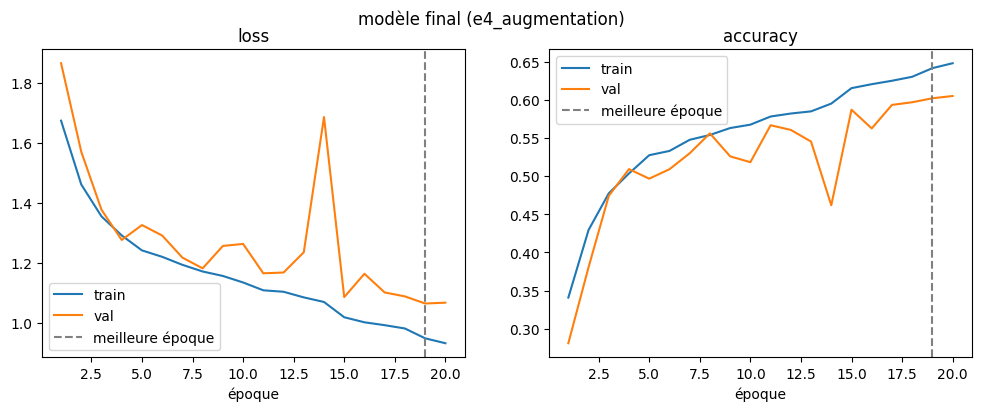

In [25]:
# chaque nom du tableau avec son modèle et son historique
modeles = {
    "cnn_base": (cnn, historique_cnn),
    "e0_baisse_lr": (modele_e0, historique_e0),
    "e1_dense128": (modele_e1, historique_e1),
    "e1b_batchnorm": (modele_e1b, historique_e1b),
    "e2_dropout": (modele_e2, historique_e2),
    "e3_4_blocs": (modele_e3, historique_e3),
    "e4_augmentation": (modele_e4, historique_e4),
    "e5_poids_classes": (modele_e5, historique_e5),
}

# règle de la partie 6 : meilleure accuracy de val
nom_final = resultats[0][0]
meilleure_accuracy = resultats[0][2]
for ligne in resultats:
    if ligne[2] > meilleure_accuracy:
        nom_final = ligne[0]
        meilleure_accuracy = ligne[2]

modele_final, historique_final = modeles[nom_final]
print("modèle final:", nom_final, "/ accuracy val:", round(meilleure_accuracy * 100, 1), "%")
tracer_courbes(historique_final, "modèle final (" + nom_final + ")")

Par rapport à cnn_base (4b), les courbes train et val restent ensemble presque tout le temps et la val_loss descend bien plus bas. L'écart train/val reste petit jusqu'à la fin, on ne voit presque plus de surapprentissage. La courbe de val est irrégulière (un gros creux à une époque) et la meilleure époque est l'avant-dernière : le modèle n'avait pas fini de progresser, un entraînement plus long serait à tester.

### 6i - Évaluation finale sur le test

C'est la seule fois qu'on utilise le test. Tous les choix ont été faits avant, sur la validation. Si on utilisait le test pour choisir le modèle, son score ne voudrait plus rien dire sur des images jamais vues, donc on ne revient pas modifier le modèle après cette cellule.

On sauvegarde aussi le modèle dans `models/modele_final.keras` pour la démo.

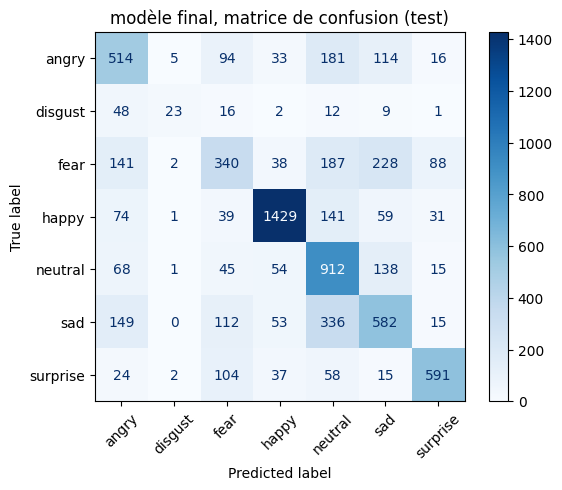

accuracy test: 61.2 % / loss 1.049 / 7177 images
accuracy val du même modèle: 60.2 %
toujours happy sur le test: 24.7 %
angry rappel: 53.7 % (514/957)
disgust rappel: 20.7 % (23/111)
fear rappel: 33.2 % (340/1024)
happy rappel: 80.6 % (1429/1774)
neutral rappel: 74.0 % (912/1233)
sad rappel: 46.7 % (582/1247)
surprise rappel: 71.1 % (591/831)
modèle sauvegardé


In [26]:
perte_test, accuracy_test = modele_final.evaluate(test_ds, verbose=0)

# test_ds n'est pas mélangé (shuffle=False) donc labels et prédictions sont dans le même ordre
labels_test = []
for images, labels in test_ds:
    labels_test.append(labels.numpy())
vraies_test = np.concatenate(labels_test).argmax(axis=1)
predites_test = modele_final.predict(test_ds, verbose=0).argmax(axis=1)

matrice_test = confusion_matrix(vraies_test, predites_test)
ConfusionMatrixDisplay(matrice_test, display_labels=CLASS_NAMES).plot(cmap="Blues", xticks_rotation=45)
plt.title("modèle final, matrice de confusion (test)")
plt.show()

perte_val_final, accuracy_val_final = modele_final.evaluate(val_ds, verbose=0)
nb_happy_test = (vraies_test == CLASS_NAMES.index("happy")).sum()

print("accuracy test:", round(accuracy_test * 100, 1), "% / loss", round(perte_test, 3), "/", len(vraies_test), "images")
print("accuracy val du même modèle:", round(accuracy_val_final * 100, 1), "%")
print("toujours happy sur le test:", round(nb_happy_test / len(vraies_test) * 100, 1), "%")
for i, classe in enumerate(CLASS_NAMES):
    bons = matrice_test[i, i]
    total = matrice_test[i].sum()
    print(classe, "rappel:", round(bons / total * 100, 1), "%", f"({bons}/{total})")

Path("models").mkdir(exist_ok=True)
modele_final.save("models/modele_final.keras")
print("modèle sauvegardé")

Le score du modèle final sur le test est très proche de celui de la validation, et même un peu au-dessus. Donc le choix fait sur la validation tient sur des images qui n'avaient servi à rien avant. Il est bien au-dessus d'un modèle qui répondrait toujours happy.

happy, neutral et surprise sont les mieux reconnues, puis angry et sad, et fear et disgust restent les plus dures. Pour disgust c'est le prix du choix de E4 : il en retrouve environ une sur cinq.

Exécution de référence du 8 octobre 2026 au soir (Google Colab, GPU T4), modèle e4_augmentation : 61.2% sur les 7 177 images de test (loss 1.049), contre 60.2% en validation. Toujours happy donnerait 24.7%.

| Classe | angry | disgust | fear | happy | neutral | sad | surprise |
|---|---:|---:|---:|---:|---:|---:|---:|
| Rappel (test) | 53.7% | 20.7% | 33.2% | 80.6% | 74.0% | 46.7% | 71.1% |

### Démo

On recharge le modèle sauvegardé et on prédit une image. Pour en tester une autre il suffit de changer `CHEMIN_IMAGE`.

L'image doit être préparée comme à l'entraînement (gris, 48x48, divisée par 255), sinon les prédictions n'ont pas de sens. Le modèle a appris sur des visages déjà recadrés, donc sur une photo où le visage est petit ou pas centré il va se tromper (c'est le rôle de la détection de visages des parties 8 et 9).

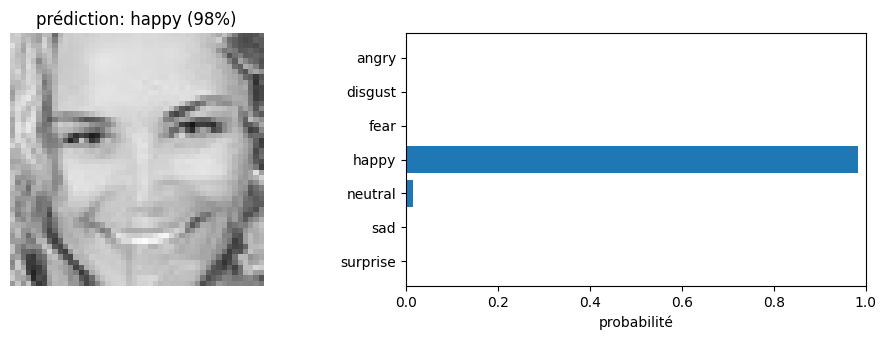

image: data/fer2013/test/happy/PrivateTest_10077120.jpg
vraie classe (dossier): happy
angry 0.0
disgust 0.0
fear 0.0
happy 0.98
neutral 0.02
sad 0.0
surprise 0.0


In [27]:
CHEMIN_IMAGE = sorted((DATA_DIR / "test" / "happy").glob("*.jpg"))[0]  # changer ici pour tester une autre image

modele_demo = keras.models.load_model("models/modele_final.keras")

# même préparation qu'à l'entraînement
image = keras.utils.load_img(CHEMIN_IMAGE, color_mode="grayscale", target_size=IMAGE_SIZE)
pixels = keras.utils.img_to_array(image) / 255.0  # (48, 48, 1)
lot = np.expand_dims(pixels, axis=0)  # (1, 48, 48, 1), predict veut un lot
probabilites_demo = modele_demo.predict(lot, verbose=0)[0]
classe_demo = CLASS_NAMES[int(probabilites_demo.argmax())]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.imshow(pixels, cmap="gray", vmin=0, vmax=1)
ax1.set_title(f"prédiction: {classe_demo} ({probabilites_demo.max():.0%})")
ax1.axis("off")
ax2.barh(CLASS_NAMES, probabilites_demo)
ax2.invert_yaxis()
ax2.set_xlim(0, 1)
ax2.set_xlabel("probabilité")
plt.tight_layout()
plt.show()

print("image:", CHEMIN_IMAGE)
print("vraie classe (dossier):", Path(CHEMIN_IMAGE).parent.name)
for classe, p in zip(CLASS_NAMES, probabilites_demo):
    print(classe, round(float(p), 2))